```text
Capital analysis
├── Import & Setup
├── Portfolio Summary
├── Capital Allocation
├── Comparing Capital Calculation Methods
└── Portfolio Strategy
```

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import display_el
from src.feature_engineering import create_target_def12
from src.modelling import apply_pipe, estimate_lgd
from src.plots import compare_lgd_distributions, my_el_plot, my_el_heatmap 
from src.preprocessing import my_input_load, ReplaceMinusOne

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# import pipeline

import joblib
pipeline = joblib.load("../models/PIPELINE_ver_011_cal_shift-test.pkl")

In [4]:
# load input file

this_dataset = my_input_load(2019, 2020)
this_dataset, dr_summary = create_target_def12(this_dataset)

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936


In [5]:
# apply pipeline

this_dataset_applied = apply_pipe(this_dataset, pipeline, calculate_el=False, sensitivity_lgd=False)

EmploymentStatus: replacing 48,446 values of -1 with NaN
MaritalStatus: replacing 48,446 values of -1 with NaN
OccupationArea: replacing 48,446 values of -1 with NaN
UseOfLoan: replacing 48,446 values of -1 with NaN


In [6]:
this_dataset_applied_lgd = estimate_lgd(this_dataset_applied, 2016, 2018, method='exposure_bands')

LoanDate range:     2016-01-01 00:00:00 2018-12-31 00:00:00
+12 months:         2017-01-01 00:00:00 2019-12-31 00:00:00
DefaultDate range:  2016-04-29 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2016,6023,1282,0.212851
2017,11109,2447,0.220272
2018,16946,2865,0.169066


LGD estimation method:  exposure_bands


,counts,amount,lgd
amount_bin,,,
0–1k,2356,1355916.0,0.517423
1–2.5k,1813,2993770.0,0.542697
2.5–5k,1581,5520235.0,0.558862
5–7.5k,466,2842812.0,0.563735
7.5–10k,137,1170231.0,0.558698
10–20k,241,2555552.0,0.563420
>20k,0,0.0,NaN


In [7]:
this_dataset_applied_lgd[["LoanYear","Amount","LossGivenDefault","LGD"]].head()

,LoanYear,Amount,LossGivenDefault,LGD
0,2019,4250.0,0.510233,0.558862
1,2019,6800.0,0.579090,0.563735
2,2019,1485.0,0.561591,0.542697
3,2019,3400.0,0.487083,0.558862
4,2019,530.0,0.512912,0.517423


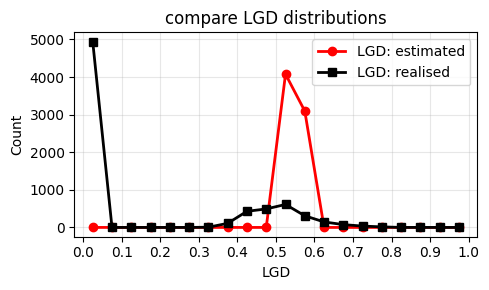

In [8]:
compare_lgd_distributions(this_dataset_applied_lgd)

In [12]:
df = this_dataset_applied_lgd
df_1 = df.loc[(df["default12"] == 1) & (df["LossGivenDefault"] == 0)]


In [13]:
df_1.shape

(4943, 116)

In [14]:
df.loc[df["default12"] == 1, "LossGivenDefault"].describe()

count    7173.000000
mean        0.159001
std         0.240653
min         0.000000
25%         0.000000
50%         0.000000
75%         0.439766
max         0.864153
Name: LossGivenDefault, dtype: float64

In [15]:
df_1[["LoanYear","Amount","LossGivenDefault","LGD"]].head()

,LoanYear,Amount,LossGivenDefault,LGD
9387,2019,4250.0,0.0,0.558862
9388,2019,530.0,0.0,0.517423
9397,2019,1590.0,0.0,0.542697
9414,2019,4250.0,0.0,0.558862
9417,2019,530.0,0.0,0.517423
